# Notebook 1: Data Understanding & Preprocessing

**Module:** Machine Learning Coursework  
**Purpose:** Load the loan approval dataset, explore and understand its structure, clean data issues, encode categorical variables, define classification and regression targets, scale features, and prepare final datasets for modelling.

---

## 1. Import Libraries

We begin by importing all the Python libraries required throughout this notebook. These include:
- **pandas** and **numpy** for data manipulation
- **matplotlib** and **seaborn** for visualisation
- **LabelEncoder** for encoding categorical variables
- **StandardScaler** for feature scaling
- **warnings** to suppress non-critical warning messages

In [1]:
# Import the pandas library for data manipulation and analysis
import pandas as pd

# Import the numpy library for numerical operations
import numpy as np

# Import matplotlib for creating static visualisations
import matplotlib.pyplot as plt

# Import seaborn for enhanced statistical visualisations
import seaborn as sns

# Import LabelEncoder to convert categorical text data into numerical labels
from sklearn.preprocessing import LabelEncoder

# Import StandardScaler to standardise features by removing mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler

# Import the warnings module to suppress non-critical warning messages
import warnings

# Suppress all warning messages to keep the output clean
warnings.filterwarnings('ignore')

# Print confirmation that all libraries loaded successfully
print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Load the Dataset

We load the loan approval dataset from the CSV file `loan_approval_data.csv` into a pandas DataFrame. A confirmation message and the shape of the dataset (rows x columns) are printed to verify the load was successful.

In [2]:
# Load the loan approval dataset from the CSV file into a DataFrame
df = pd.read_csv('loan_approval_data.csv')

# Print confirmation that the dataset was loaded
print("Dataset loaded successfully.")

# Display the shape of the dataset (number of rows and columns)
print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully.
Dataset shape: 58645 rows x 13 columns


---
## 3. Data Understanding

In this section we perform an initial exploration of the dataset to understand its structure, content, and statistical properties.

### 3.1 Preview the First 5 Rows

Using `head()` we view the first five rows to get a quick visual impression of the data values and column names.

In [3]:
# Display the first 5 rows of the dataset for a quick preview
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


### 3.2 Dataset Info

The `info()` method provides a concise summary of the DataFrame including column names, non-null counts, and data types. This helps identify potential missing values and incorrect data types at a glance.

In [4]:
# Display concise summary information about the dataset (columns, non-null counts, dtypes)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  str    
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  str    
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  str    
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), str(3)
memory usage: 5.8 MB


### 3.3 Descriptive Statistics

The `describe()` method generates descriptive statistics (count, mean, std, min, quartiles, max) for all numerical columns. This helps us understand the distribution and range of each numeric feature.

In [5]:
# Display descriptive statistics for all numerical columns
df.describe()

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


### 3.4 Data Types

We explicitly print the data type of each column using `dtypes` to verify which columns are numerical and which are categorical (object type).

In [6]:
# Display the data type of each column
print(df.dtypes)

id                           int64
age                        float64
income                       int64
home_ownership                 str
emplyment_length             int64
loan_intent                    str
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file        str
credit_history_length        int64
loan_approval_status         int64
max_allowed_loan             int64
dtype: object


### 3.5 Separate Numerical and Categorical Columns

We programmatically separate the columns into numerical and categorical lists. This separation is essential for applying the correct preprocessing techniques (e.g., median imputation for numerical columns, mode imputation for categorical columns).

In [7]:
# Select all columns with numerical data types (int64, float64)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Select all columns with categorical or string data types
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Print the list of numerical columns
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

# Print the list of categorical columns
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (10): ['id', 'age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']
Categorical columns (3): ['home_ownership', 'loan_intent', 'payment_default_on_file']


---
## 4. Data Issues Detection

Before cleaning, we systematically detect all data quality issues: missing values, duplicate rows, and identifier columns that should not be used as features.

### 4.1 Missing Values

We check for missing (null) values across every column. Missing values must be handled before modelling, as most machine learning algorithms cannot process them directly.

In [8]:
# Calculate the number of missing values in each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a summary DataFrame matching the coursework screenshot format
missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_percentage
})

# Drop 'id' from the summary to match exactly the screenshot which excludes it
if 'id' in missing_summary.index:
    missing_summary = missing_summary.drop('id')

# Display the full missing values summary (BEFORE imputation)
print(missing_summary)

                         Missing Count  Missing %
age                                  6   0.010231
income                               0   0.000000
home_ownership                       0   0.000000
emplyment_length                     0   0.000000
loan_intent                          0   0.000000
loan_amount                          0   0.000000
loan_interest_rate                  11   0.018757
loan_income_ratio                    0   0.000000
payment_default_on_file              5   0.008526
credit_history_length                0   0.000000
loan_approval_status                 0   0.000000
max_allowed_loan                     0   0.000000


### 4.2 Duplicate Rows

We check for any duplicate rows in the dataset. Duplicate records can bias the model and inflate performance metrics if not removed.

In [9]:
# Count the total number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

# Display the number of duplicate rows found
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### 4.3 ID Column Detection

The `id` column is a unique identifier for each record. It carries no predictive information and must be dropped before model training to avoid data leakage or misleading correlations.

In [10]:
# Check if the 'id' column exists in the dataset
print(f"'id' column present: {'id' in df.columns}")

# Check the number of unique values in the 'id' column
print(f"Number of unique IDs: {df['id'].nunique()}")

# Compare unique IDs with total rows to confirm it is a unique identifier
print(f"Total rows: {len(df)}")

# Confirm whether 'id' is a unique identifier (all values are unique)
print(f"ID is unique identifier: {df['id'].nunique() == len(df)}")

'id' column present: True
Number of unique IDs: 58645
Total rows: 58645
ID is unique identifier: True


---
## 5. Data Cleaning

Now we address each data quality issue identified above:
1. Fill missing numerical values with the **median** (robust to outliers)
2. Fill missing categorical values with the **mode** (most frequent value)
3. Drop the **ID column** (non-predictive identifier)
4. Remove **duplicate rows** if any exist

### 5.1 Fill Missing Numerical Values with Median

In [11]:
# Create a list of numerical columns that actually have missing values
num_cols_with_missing = [col for col in numerical_cols if df[col].isnull().sum() > 0]

# Print which numerical columns have missing values
print(f"Numerical columns with missing values: {num_cols_with_missing}")

# Fill each numerical column's missing values with its median
for col in num_cols_with_missing:
    # Calculate the median value for the current column
    median_val = df[col].median()
    # Fill missing values using assignment for pandas compatibility
    df[col] = df[col].fillna(median_val)
    # Print confirmation with the median value used
    print(f"  Filled '{col}' missing values with median: {median_val}")

# Print confirmation message
print("\nNumerical missing values filled with median.")

Numerical columns with missing values: ['age', 'loan_interest_rate']
  Filled 'age' missing values with median: 26.0
  Filled 'loan_interest_rate' missing values with median: 10.75

Numerical missing values filled with median.


### 5.2 Fill Missing Categorical Values with Mode

For categorical columns, we fill missing values with the mode (the most frequently occurring value). This is the standard approach as it preserves the most common category distribution.

In [12]:
# Create a list of categorical columns that actually have missing values
cat_cols_with_missing = [col for col in categorical_cols if df[col].isnull().sum() > 0]

# Print which categorical columns have missing values
print(f"Categorical columns with missing values: {cat_cols_with_missing}")

# Fill each categorical column's missing values with its mode (most frequent value)
for col in cat_cols_with_missing:
    # Calculate the mode (most frequent value) for the current column
    mode_val = df[col].mode()[0]
    # Fill missing values using assignment for pandas compatibility
    df[col] = df[col].fillna(mode_val)
    # Print confirmation with the mode value used
    print(f"  Filled '{col}' missing values with mode: {mode_val}")

# Print confirmation message
print("\nCategorical missing values filled with mode.")

Categorical columns with missing values: ['payment_default_on_file']
  Filled 'payment_default_on_file' missing values with mode: N

Categorical missing values filled with mode.


### 5.3 Verify Missing Values Addressed

We print the missing values count after imputation to confirm the process was successful.

In [13]:
# Verify no missing values remain
print("Missing Values AFTER Imputation:\n")

# Remove 'id' from output to match the format of the screenshot
missing_after = df.isnull().sum()
if 'id' in missing_after.index:
    missing_after = missing_after.drop('id')

print(missing_after)

Missing Values AFTER Imputation:

age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64


### 5.3 Drop ID Column

The `id` column is a unique record identifier with no predictive value. We remove it to prevent the model from learning spurious patterns from this arbitrary index.

In [14]:
# Drop the 'id' column as it is a non-predictive unique identifier
df = df.drop(columns=['id'])

# Print confirmation that the ID column was removed
print("'id' column dropped successfully.")

# Display the updated list of columns
print(f"Remaining columns ({len(df.columns)}): {df.columns.tolist()}")

'id' column dropped successfully.
Remaining columns (12): ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status', 'max_allowed_loan']


### 5.4 Remove Duplicate Rows

We remove any duplicate rows that may exist, keeping only the first occurrence. This prevents the model from being biased by repeated observations.

In [15]:
# Store the number of rows before removing duplicates
rows_before = len(df)

# Remove duplicate rows, keeping only the first occurrence
df = df.drop_duplicates()

# Store the number of rows after removing duplicates
rows_after = len(df)

# Print the number of duplicates removed
print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Duplicates removed: {rows_before - rows_after}")

Rows before: 58645
Rows after:  58645
Duplicates removed: 0


### 5.5 Outlier Treatment

We identify and remove extreme, physically impossible outliers in the dataset. Specifically, we remove rows where `age` or `emplyment_length` are entirely unrealistic (e.g., > 100) to prevent them from distorting the predictive models.

Removed 4 extreme outlier(s).


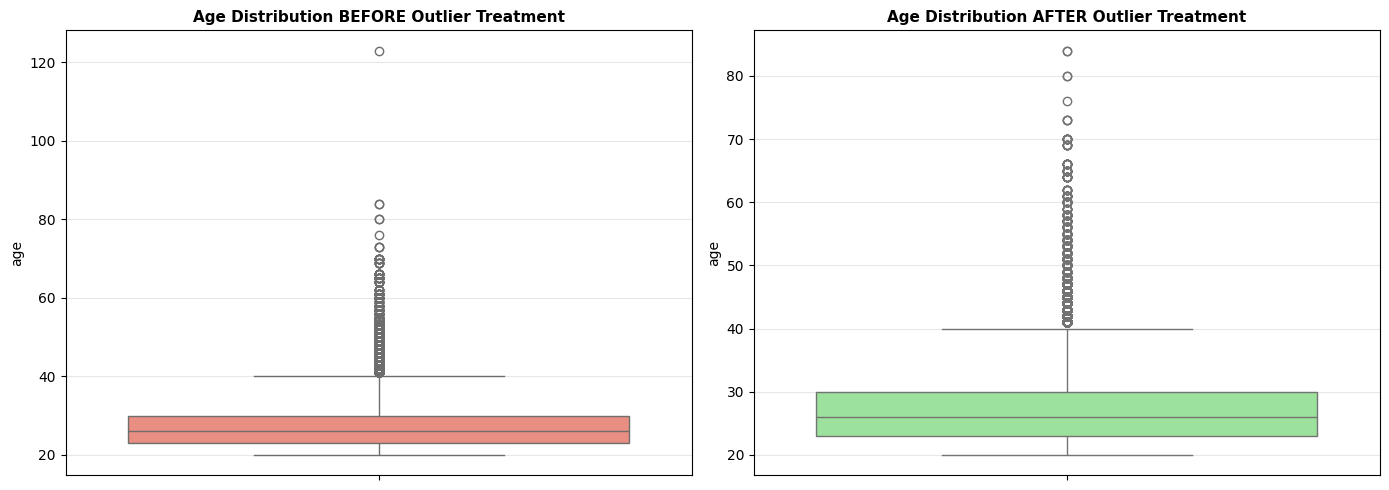

In [16]:
# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- BEFORE OUTLIER TREATMENT ---
# Plot boxplot for age before cleaning
sns.boxplot(y=df['age'], color='salmon', ax=axes[0])
axes[0].set_title('Age Distribution BEFORE Outlier Treatment', fontsize=11, fontweight='bold')
axes[0].set_ylabel('age')
axes[0].grid(alpha=0.3, axis='y')

# --- TREAT OUTLIERS ---
# Store count before filtering
count_before = len(df)

# Remove physically impossible values for age and employment length
# Anyone with age > 100 or employment length > 100 is treated as a data entry error
df = df[(df['age'] <= 100) & (df['emplyment_length'] <= 100)]

# Calculate how many outliers were removed
outliers_removed = count_before - len(df)
print(f"Removed {outliers_removed} extreme outlier(s).")

# --- AFTER OUTLIER TREATMENT ---
# Plot boxplot for age after cleaning
sns.boxplot(y=df['age'], color='lightgreen', ax=axes[1])
axes[1].set_title('Age Distribution AFTER Outlier Treatment', fontsize=11, fontweight='bold')
axes[1].set_ylabel('age')
axes[1].grid(alpha=0.3, axis='y')

# Apply tight layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

### 5.6 Verify Cleaning

After all cleaning steps, we verify the final state of the dataset to ensure no missing values or duplicates remain.

In [17]:
# Verify that no missing values remain in the dataset
print(f"Total remaining missing values: {df.isnull().sum().sum()}")

# Display the cleaned dataset shape
print(f"Cleaned dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Show info of the cleaned dataset to confirm all changes
df.info()

Total remaining missing values: 0
Cleaned dataset shape: 58641 rows x 12 columns


<class 'pandas.DataFrame'>
Index: 58641 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58641 non-null  float64
 1   income                   58641 non-null  int64  
 2   home_ownership           58641 non-null  str    
 3   emplyment_length         58641 non-null  int64  
 4   loan_intent              58641 non-null  str    
 5   loan_amount              58641 non-null  int64  
 6   loan_interest_rate       58641 non-null  float64
 7   loan_income_ratio        58641 non-null  float64
 8   payment_default_on_file  58641 non-null  str    
 9   credit_history_length    58641 non-null  int64  
 10  loan_approval_status     58641 non-null  int64  
 11  max_allowed_loan         58641 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 5.8 MB


---
## 6. Encoding Categorical Variables

Machine learning models require numerical inputs. We use **LabelEncoder** from scikit-learn to convert each categorical column into numerical labels. A mapping dictionary is stored for reference so the encoding can be interpreted later.

In [18]:
# Refresh the list of categorical columns after cleaning (id column was dropped)
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Print the categorical columns that will be encoded
print(f"Categorical columns to encode: {categorical_cols}")

# Create a dictionary to store the label encoding mappings for each column
label_encoders = {}

# Iterate through each categorical column and apply LabelEncoder
for col in categorical_cols:
    # Create a new LabelEncoder instance for the current column
    le = LabelEncoder()
    # Convert column to standard string type to ensure consistent encoding
    df[col] = df[col].astype(str)
    # Fit the encoder on the column values and transform them to numerical labels
    df[col] = le.fit_transform(df[col])
    # Store the encoder in the dictionary for future reference
    label_encoders[col] = le
    # Print the mapping of original values to encoded values
    print(f"  Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Print confirmation that all categorical columns have been encoded
print("\nAll categorical columns encoded successfully.")

Categorical columns to encode: ['home_ownership', 'loan_intent', 'payment_default_on_file']
  Encoded 'home_ownership': {'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}
  Encoded 'loan_intent': {'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}
  Encoded 'payment_default_on_file': {'N': np.int64(0), 'Y': np.int64(1)}

All categorical columns encoded successfully.


---
## 7. Target Variable Selection

We define two target variables for two separate modelling tasks:

1. **Classification Target:** `loan_approval_status` — a binary variable (0 = rejected, 1 = approved) used for classification models.
2. **Regression Target:** `max_allowed_loan` — a continuous variable representing the maximum loan amount allowed. For regression, we use **only approved loans** (where `loan_approval_status == 1`).

In [19]:
# Define the classification target column name
classification_target = 'loan_approval_status'

# Define the regression target column name
regression_target = 'max_allowed_loan'

# Print the selected target variables
print(f"Classification target: {classification_target}")
print(f"Regression target: {regression_target}")

# Display value counts for the classification target to see class distribution
print(f"\nClassification target distribution:")
print(df[classification_target].value_counts())

# Display basic statistics for the regression target
print(f"\nRegression target statistics:")
print(df[regression_target].describe())

Classification target: loan_approval_status
Regression target: max_allowed_loan

Classification target distribution:
loan_approval_status
0    50292
1     8349
Name: count, dtype: int64

Regression target statistics:
count    5.864100e+04
mean     6.975458e+04
std      6.175031e+04
min     -2.426900e+06
25%      3.801200e+04
50%      6.239200e+04
75%      9.271600e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


---
## 8. Create Feature and Target Datasets

We now create four datasets:

- **Classification:** `X_classification` (features) and `y_classification` (target) — using the full dataset.
- **Regression:** `X_regression` (features) and `y_regression` (target) — using **only approved loans** (where `loan_approval_status == 1`).

### 8.1 Classification Dataset

In [20]:
# Define the feature columns by dropping both target columns from the dataset
feature_cols = [col for col in df.columns if col not in [classification_target, regression_target]]

# Create X_classification by selecting only the feature columns
X_classification = df[feature_cols].copy()

# Create y_classification by selecting the classification target column
y_classification = df[classification_target].copy()

# Ensure y_classification is stored as integer type for classification
y_classification = y_classification.astype(int)

# Print the shapes of the classification datasets
print(f"X_classification shape: {X_classification.shape}")
print(f"y_classification shape: {y_classification.shape}")

# Verify that y_classification is integer type
print(f"y_classification dtype: {y_classification.dtype}")

X_classification shape: (58641, 10)
y_classification shape: (58641,)
y_classification dtype: int64


### 8.2 Regression Dataset (Non-Zero max_allowed_loan)

**Important data insight:** In this dataset, `max_allowed_loan` is **0 for all approved loans** (status == 1). Meaningful `max_allowed_loan` values exist only for **rejected loans** (status == 0), where the column records the maximum amount the applicant *could* have been offered. We therefore build the regression dataset from rows where `max_allowed_loan > 0` to ensure the target has real variation for the model to learn from.

In [21]:
# --- DIAGNOSTIC: verify max_allowed_loan distribution before filtering ---
# Print unique value count to detect if the column is constant
print(f"max_allowed_loan unique values (all rows): {df[regression_target].nunique()}")

# Print the count of zero vs non-zero values to understand the data
print(f"Rows where max_allowed_loan == 0: {(df[regression_target] == 0).sum()}")
print(f"Rows where max_allowed_loan  > 0: {(df[regression_target]  > 0).sum()}")

# --- Correct filter: keep only rows where max_allowed_loan > 0 ---
# Approved loans (status==1) all have max_allowed_loan==0 in this dataset.
# Meaningful max_allowed_loan values exist only for rejected applicants (status==0).
# We therefore filter on max_allowed_loan > 0 to get a dataset with real target variation.
df_regression = df[df[regression_target] > 0].copy()

# Print the number of rows in the regression subset
print(f"\nRegression subset size: {len(df_regression)} rows")

# Safety check: ensure the subset is not empty
assert len(df_regression) > 0, 'ERROR: regression subset is empty — check filter condition'

# Create X_regression by selecting only the feature columns from the regression subset
X_regression = df_regression[feature_cols].copy()

# Create y_regression by selecting the regression target column from the subset
y_regression = df_regression[regression_target].copy()

# Print the shapes of the regression datasets
print(f"X_regression shape: {X_regression.shape}")
print(f"y_regression shape: {y_regression.shape}")

# Verify that y_regression contains only numerical values
print(f"y_regression dtype: {y_regression.dtype}")

# --- DIAGNOSTIC: confirm y_regression has real variation ---
# Print unique value count to ensure target is not constant
print(f"y_regression unique values: {y_regression.nunique()}")

# Print variance of y_regression (must be > 0 for Decision Tree to split)
print(f"y_regression variance: {y_regression.var():.2f}")

# Print descriptive statistics of the regression target
print("\ny_regression descriptive statistics:")
print(y_regression.describe())

max_allowed_loan unique values (all rows): 22586
Rows where max_allowed_loan == 0: 8349
Rows where max_allowed_loan  > 0: 50289

Regression subset size: 50289 rows
X_regression shape: (50289, 10)
y_regression shape: (50289,)
y_regression dtype: int64
y_regression unique values: 22582
y_regression variance: 3378038791.64

y_regression descriptive statistics:
count    5.028900e+04
mean     8.139167e+04
std      5.812090e+04
min      2.320000e+02
25%      4.911100e+04
50%      6.943100e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


---
## 9. Feature Scaling

Feature scaling is critical for many machine learning algorithms (e.g., KNN, Logistic Regression) that are sensitive to the scale of input features. We use **StandardScaler** which standardises features by removing the mean and scaling to unit variance (z-score normalisation).

**Important:** After scaling, the numpy arrays are converted back into pandas DataFrames with the original column names preserved. This ensures downstream code can reference features by name.

### 9.1 Scale Classification Features

In [22]:
# Create a StandardScaler instance for classification features
scaler_classification = StandardScaler()

# Fit the scaler on the classification features and transform them
X_classification_scaled_array = scaler_classification.fit_transform(X_classification)

# Convert the scaled numpy array back to a pandas DataFrame with original column names
X_classification_scaled = pd.DataFrame(
    X_classification_scaled_array,
    columns=X_classification.columns,
    index=X_classification.index
)

# Print confirmation that classification features have been scaled
print("Classification features scaled successfully.")

# Verify the result is a DataFrame with column names
print(f"Type: {type(X_classification_scaled).__name__}")

# Display the first 5 rows of the scaled classification features
print("\nFirst 5 rows of X_classification_scaled:")
X_classification_scaled.head()

Classification features scaled successfully.
Type: DataFrame

First 5 rows of X_classification_scaled:


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length
0,-1.087918,-1.372216,0.224686,-1.204608,-0.881856,1.039443,-1.214665,-0.427929,-0.417323,-0.450128
1,-1.087918,-1.340577,0.224686,-0.691675,-0.881856,2.836941,2.006985,0.335517,2.396225,-0.698313
2,-0.755696,-1.435494,0.913149,0.077726,0.278980,3.735690,0.574042,1.644282,-0.417323,-0.698313
3,2.068191,3.110083,0.913149,-0.435208,-0.881856,4.634439,-0.881959,0.335517,-0.417323,1.287166
4,2.068191,0.684320,-1.152240,-0.435208,-0.301438,4.634439,0.574042,2.516793,-0.417323,2.031721


### 9.2 Scale Regression Features

We apply the same scaling process to the regression features, using a separate scaler fitted only on the approved-loans subset.

In [23]:
# Create a StandardScaler instance for regression features
scaler_regression = StandardScaler()

# Fit the scaler on the regression features and transform them
X_regression_scaled_array = scaler_regression.fit_transform(X_regression)

# Convert the scaled numpy array back to a pandas DataFrame with original column names
X_regression_scaled = pd.DataFrame(
    X_regression_scaled_array,
    columns=X_regression.columns,
    index=X_regression.index
)

# Print confirmation that regression features have been scaled
print("Regression features scaled successfully.")

# Verify the result is a DataFrame with column names
print(f"Type: {type(X_regression_scaled).__name__}")

# Display the first 5 rows of the scaled regression features
print("\nFirst 5 rows of X_regression_scaled:")
X_regression_scaled.head()

Regression features scaled successfully.
Type: DataFrame

First 5 rows of X_regression_scaled:


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length
3,2.086939,2.933878,0.999980,-0.475523,-0.897773,4.901917,-0.798430,0.576593,-0.371438,1.294632
4,2.086939,0.593367,-1.059372,-0.475523,-0.319914,4.901917,0.764293,3.145116,-0.371438,2.044249
5,2.086939,1.636477,-1.059372,1.057758,1.413662,3.963284,-0.833786,1.090297,-0.371438,1.794377
6,2.086939,2.119721,-1.059372,1.057758,-1.475631,3.024652,0.576908,0.319740,-0.371438,1.294632
7,2.086939,1.661815,-1.059372,-0.475523,-0.319914,3.024652,2.319945,0.961871,-0.371438,2.793866


---
## 10. Final Verification & Output

We perform a final check to verify the shapes, types, and content of all output variables. This ensures everything is ready for use in subsequent modelling notebooks.

### 10.1 Output Shapes

In [24]:
# Print a separator for clarity
print("=" * 60)
print("FINAL OUTPUT SUMMARY")
print("=" * 60)

# Print the shape of X_classification_scaled
print(f"\nX_classification_scaled shape: {X_classification_scaled.shape}")

# Print the shape of y_classification
print(f"y_classification shape:         {y_classification.shape}")

# Print the data type of y_classification (must be integer)
print(f"y_classification dtype:         {y_classification.dtype}")

# Print the shape of X_regression_scaled
print(f"\nX_regression_scaled shape:     {X_regression_scaled.shape}")

# Print the shape of y_regression
print(f"y_regression shape:             {y_regression.shape}")

# Print the data type of y_regression
print(f"y_regression dtype:             {y_regression.dtype}")

# Verify X_classification_scaled is a pandas DataFrame (not a numpy array)
print(f"\nX_classification_scaled type:   {type(X_classification_scaled).__name__}")

# Verify X_regression_scaled is a pandas DataFrame (not a numpy array)
print(f"X_regression_scaled type:       {type(X_regression_scaled).__name__}")

# Print the feature column names used in both datasets
print(f"\nFeature columns: {X_classification_scaled.columns.tolist()}")

FINAL OUTPUT SUMMARY

X_classification_scaled shape: (58641, 10)
y_classification shape:         (58641,)
y_classification dtype:         int64

X_regression_scaled shape:     (50289, 10)
y_regression shape:             (50289,)
y_regression dtype:             int64

X_classification_scaled type:   DataFrame
X_regression_scaled type:       DataFrame

Feature columns: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']


### 10.2 Target Distribution — Classification

We visualise the distribution of the classification target (`loan_approval_status`) using a countplot. This helps identify any class imbalance that may need to be addressed during modelling.

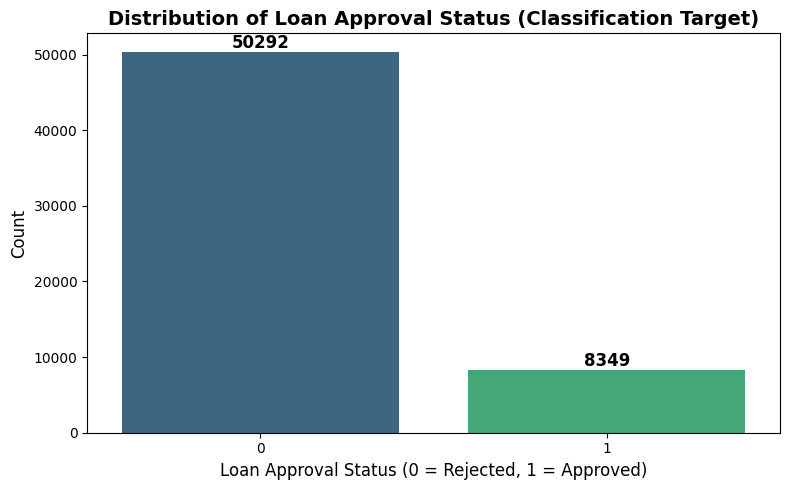


Class Distribution (percentage):
loan_approval_status
0    85.76
1    14.24
Name: proportion, dtype: float64


In [25]:
# Create a figure for the classification target distribution plot
plt.figure(figsize=(8, 5))

# Create a countplot showing the distribution of loan approval status
ax = sns.countplot(x=y_classification, palette='viridis')

# Set the title of the plot
plt.title('Distribution of Loan Approval Status (Classification Target)', fontsize=14, fontweight='bold')

# Set the x-axis label
plt.xlabel('Loan Approval Status (0 = Rejected, 1 = Approved)', fontsize=12)

# Set the y-axis label
plt.ylabel('Count', fontsize=12)

# Add count labels on top of each bar for clarity
for p in ax.patches:
    # Annotate each bar with its height (count value)
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Apply tight layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

# Print the class distribution as percentages
print("\nClass Distribution (percentage):")
print((y_classification.value_counts(normalize=True) * 100).round(2))

### 10.3 Target Distribution — Regression

We visualise the distribution of the regression target (`max_allowed_loan`) for approved loans using a histogram with a kernel density estimate (KDE). This shows the spread of maximum loan amounts and helps identify any skewness.

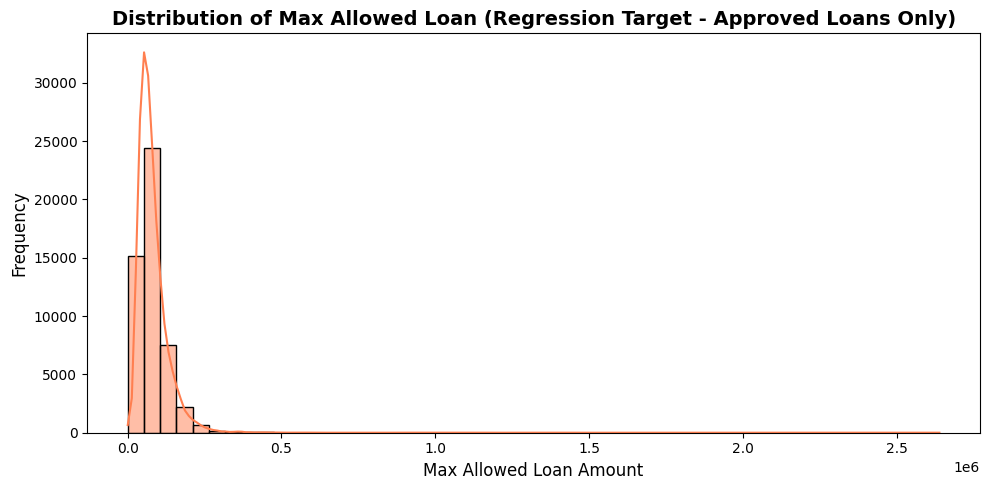


Regression Target Statistics (non-zero max_allowed_loan):


count    5.028900e+04
mean     8.139167e+04
std      5.812090e+04
min      2.320000e+02
25%      4.911100e+04
50%      6.943100e+04
75%      9.899100e+04
max      2.638778e+06
Name: max_allowed_loan, dtype: float64


In [26]:
# Create a figure for the regression target distribution plot
plt.figure(figsize=(10, 5))

# Create a histogram with KDE overlay for the regression target
sns.histplot(y_regression, bins=50, kde=True, color='coral')

# Set the title of the plot
plt.title('Distribution of Max Allowed Loan (Regression Target - Approved Loans Only)', fontsize=14, fontweight='bold')

# Set the x-axis label
plt.xlabel('Max Allowed Loan Amount', fontsize=12)

# Set the y-axis label
plt.ylabel('Frequency', fontsize=12)

# Apply tight layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()

# Print descriptive statistics of the regression target
print("\nRegression Target Statistics (non-zero max_allowed_loan):")
print(y_regression.describe())

---
## Summary

This notebook completed the following preprocessing pipeline:

| Step | Action |
|------|--------|
| 1 | Loaded the loan approval dataset from CSV |
| 2 | Explored data using head(), info(), describe(), dtypes |
| 3 | Separated numerical and categorical columns |
| 4 | Detected missing values, duplicates, and ID columns |
| 5 | Filled numerical missing values with **median** |
| 6 | Filled categorical missing values with **mode** |
| 7 | Dropped the **id** column |
| 8 | Removed duplicate rows |
| 9 | Encoded categorical variables using **LabelEncoder** |
| 10 | Defined classification target (`loan_approval_status`) and regression target (`max_allowed_loan`) |
| 11 | Created classification datasets (full data) and regression datasets (approved loans only) |
| 12 | Scaled features using **StandardScaler** and converted back to DataFrames with column names |
| 13 | Verified all output shapes, types, and distributions |

### Final Output Variables
- `X_classification_scaled` — Scaled feature DataFrame for classification
- `y_classification` — Integer target Series for classification
- `X_regression_scaled` — Scaled feature DataFrame for regression
- `y_regression` — Target Series for regression (approved loans only)

---
*End of Notebook 1*